# Train Network with Local-SSL

We provide a short tutorial to help you understand how the local-SSL loss training works. In particular, we load CIFAR10 dataset with simpler data-augmentations. A simple 3-layer CNN is trained for a few epochs.

For performance reported in the paper, refer to README.md and code in ``vision/scripts``.

In [1]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
os.chdir('../')
from vision.models import SSLLoss

## Part 1: Load Data
First, we load the CIFAR10 dataset and create pairs of augmented copies.

In [ ]:
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset
from vision.data.get_dataloader import SimCLRTrainDataTransform, SimCLREvalDataTransform


def get_cifar_paired_dataloader():
    '''
    Create Dataset and Dataloader
    Output:
        unsupervised_dataset/loader is for pre-training
        train_dataset/loader is for downstream training
        test_dataset/loader is for downstream testing
    
    '''
    print('Loading CIFAR Dataset ...')
    base_folder = '~/Desktop/EPFL/LCN/CIFAR/dataset' # Change to your Own Base Folder

    norm = transforms.Normalize(mean=[125.3/255, 123.0/255, 113.9/255], std=[63.0/255, 62.1/255, 66.7/255])
    train_transform = SimCLRTrainDataTransform(32, scale_size=(0.25, 1.0), gaussian_blur=False, normalize=norm) # we remove gaussian blur for faster augmentation
    test_transform = SimCLREvalDataTransform(32, normalize=norm)
    decode_transform = SimCLREvalDataTransform(32, normalize=norm, aug=True)

    ds_class = torchvision.datasets.CIFAR10
    
    unsupervised_dataset = ds_class(
        base_folder,
        train=True,
        transform=train_transform,
        download=True,
    ) 

    train_dataset = ds_class(
        base_folder, train=True, transform=decode_transform, download=True
    )

    test_dataset = ds_class(
        base_folder, train=False, transform=test_transform, download=True
    )

    # default dataset loaders, for CPU, I do not set num_workers and pin_memory, you can change it if you run it on GPU
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=128, shuffle=True,
        #num_workers=4, pin_memory=True
    )

    unsupervised_loader = torch.utils.data.DataLoader(
        unsupervised_dataset, batch_size=128, shuffle=True,
        #num_workers=4, pin_memory=True
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=128, shuffle=False, 
        #num_workers=4, pin_memory=True
    )

    return (
        unsupervised_loader,
        unsupervised_dataset,
        train_loader,
        train_dataset,
        test_loader,
        test_dataset,
    )

In [3]:
unsupervised_loader, unsupervised_dataset, train_loader, train_dataset, test_loader, test_dataset = get_cifar_paired_dataloader()

Loading CIFAR Dataset ...
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


## Part 2: Create Model
Here, we create a simple 3 layer CNN. The model should output activities in all layers, so that the local SSL loss could be computed. It is prefered that the model could compute its dimension of each output layer. In this way, you could initialize the loss more easily.

**Remark**: the key line to make the loss local is to disrupt the gradient flow. So, input are always first detached before passing a trainable layer!

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, layer_dims=[64, 128, 256], maxpool_idx = [1], ete_training=False):
        super(SimpleCNN, self).__init__()
        
        self.layer_dims = layer_dims
        self.ete_training = ete_training
    
        self.layers = nn.ModuleList()
        for i in range(len(layer_dims)):
            layer = []
            if i == 0:
                layer.append(nn.Conv2d(in_channels, layer_dims[i], kernel_size=3, stride=1, padding=1))
            else:
                layer.append(nn.Conv2d(layer_dims[i-1], layer_dims[i], kernel_size=3, stride=1, padding=1))
            layer.append(nn.ReLU())
            if i in maxpool_idx:
                layer.append(nn.MaxPool2d(kernel_size=2, stride=2))
            self.layers.append(nn.Sequential(*layer))
            

    def forward(self, x):
        # Store activations from each layer for contrastive loss computation
        activations = []
        for layer in self.layers:
            x = layer(x) if self.ete_training else layer(x.detach()) # IMPORTANT: detach the input to each layer to prevent gradient flow, thus enabling local training
            activations.append(x)
        
        return activations

    def get_h_dims(self, input_dim):
        # given input image dimension (C, H, W), compute the output dimension of each layer, by passing a dummy input through the layers
        C, H, W = input_dim
        dims = []
        x = torch.randn(1, C, H, W)
        for layer in self.layers:
            x = layer(x)
            dims.append(x.shape)
        return dims

# Create the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN(in_channels=3, layer_dims=[128, 256, 256]).to(device)
h_dims = model.get_h_dims((3, 32, 32))
print(model)
print("Output dimensions of each layer:", h_dims)

SimpleCNN(
  (layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
    )
  )
)
Output dimensions of each layer: [torch.Size([1, 128, 32, 32]), torch.Size([1, 256, 16, 16]), torch.Size([1, 256, 16, 16])]


## Part 3: Creat loss module
To use the SSLLoss, you need a python NameSpace object containing the following hyperparameters (you could check the exact usage in ``vision/arg_parser`` folder):


In [5]:
from argparse import Namespace

opt = Namespace(
    negative_samples=1,
    contrast_mode='hinge',
    either_pos_or_neg_update=False,
    customize_fb_idx=None,
    model_splits=len(h_dims), # this should be the same as the number of layers in the model
    customize_loss_pool=None,
    adaptive_loss_pool=False,
    use_projection_head=False,
    low_rank_dim=None,
    identity_projection=False,
    predict_module_num='same',
    freeze_W_pred=False,
    unfreeze_last_W_pred=False,
    retain_proj_grads=False,
    learning_rate=2e-4,
    normalize_pred=False,
    asymmetric_W_pred=True,
    log_pos_neg=True,
    update_proj_steps=0,
    determined_neg_samples=False,
    unified_random_sampling=True,
    device=device,
    pos_coeff=1.0,
    phyll_theta=1.0,
    pred_decay=0.0,
    dfa=False,
    ete_training=False,
    use_proj_head=False
)

In [6]:
''''
The contrastive loss module takes two arguments:
    opt: the various hyperparameters and settings for the loss computation
    h_dims: the output dimensions of each layer in the model, which is used to initialize the projection B for each layer 
'''
ssl_loss = SSLLoss.CPLoss(opt, h_dims=h_dims).to(device)
print(ssl_loss)

CPLoss(
  (W_k): ModuleList(
    (0): Linear(in_features=128, out_features=128, bias=False)
    (1-2): 2 x Linear(in_features=256, out_features=256, bias=False)
  )
)


# Part 4: Self-Supervised Training

In [7]:
from tqdm import tqdm
import torch.optim as optim
optimizer = optim.Adam(list(model.parameters()) + list(ssl_loss.parameters()), lr=opt.learning_rate)
loss_history = [[] for _ in range(opt.model_splits)]
for epoch in range(3): # just 3 epoch for demonstration
    for batch, label in tqdm(unsupervised_loader):
        img = torch.vstack([batch[0], batch[1]])
        h_list = model(img.to(device))
        loss_dict, _, _, _ = ssl_loss(h_list)
        loss = loss_dict['loss'].mean(dim=0)
        optimizer.zero_grad()
        loss.sum().backward()
        optimizer.step()
        for i in range(opt.model_splits):
            loss_history[i].append(loss[i].item())
    

100%|██████████| 391/391 [06:50<00:00,  1.05s/it]


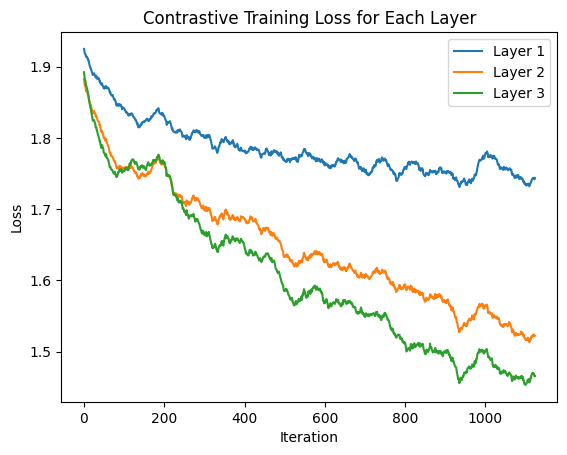

In [8]:
import matplotlib.pyplot as plt
window_size = 50
for i in range(opt.model_splits):
    loss_i_smooth = np.convolve(np.array(loss_history[i]), np.ones(window_size)/window_size, mode='valid') # smooth the loss curve
    plt.plot(loss_i_smooth, label=f'Layer {i+1}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Contrastive Training Loss for Each Layer')
plt.legend()